In [15]:
import importlib.util
import sys
import subprocess

def check_installation_and_install(package_name):
    spec = importlib.util.find_spec(package_name)
    if spec is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])
    else:
        print(package_name + " is installed");

check_installation_and_install("pandas")
check_installation_and_install("matplotlib")
check_installation_and_install("numpy")
check_installation_and_install("wfdb")

pandas is installed
matplotlib is installed
numpy is installed
wfdb is installed


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
#import seaborn as sns
import os

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score
from sklearn import linear_model
from sklearn.tree import DecisionTreeClassifier 
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import RandomizedSearchCV

import tensorflow as tf



## Load Data

In [2]:
file_directory = "./Cleaned_Data"

df = pd.read_csv(os.path.join(file_directory,"Cleaned_Data.csv"))

df = df.drop(columns = ['Unnamed: 0'])

df.head()

,RXPACC,FP_IDX,CIR746,CIR740,CIR749,CIR_PWR,CIR750,CIR575,CIR326,CIR333,CIR349,CIR350,CIR246,NLOS,RANGE
0,611.0,745.0,6102.0,266.0,9621.0,11855.0,8303.0,106.0,150.0,182.0,179.0,215.0,284.0,0.0,3.90
1,447.0,749.0,194.0,10.0,1840.0,18968.0,5244.0,245.0,263.0,247.0,123.0,299.0,230.0,0.0,0.66
2,723.0,746.0,1212.0,500.0,4489.0,14699.0,2992.0,73.0,172.0,265.0,205.0,180.0,314.0,1.0,7.86
3,1024.0,750.0,292.0,241.0,1424.0,8748.0,2907.0,418.0,213.0,250.0,157.0,345.0,317.0,1.0,3.48
4,276.0,746.0,11949.0,280.0,16162.0,11380.0,19583.0,185.0,68.0,240.0,42.0,338.0,152.0,0.0,1.19


## Split data 

In [3]:
original_df = df

X = original_df.drop(['NLOS'], axis=1)
y = original_df['NLOS']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# print(X_train.describe())


# Classification of NLOS and LOS data

## Decision Tree Classification

In [4]:
dtc = DecisionTreeClassifier(criterion="entropy", max_depth=5)
dtc = dtc.fit(X_train,y_train)

dtc_y_pred = dtc.predict(X_test)


rfc = RandomForestClassifier(n_estimators=100, random_state=42)
rfc = rfc.fit(X_train,y_train)

rfc_y_pred = rfc.predict(X_test)

### Accuracy Testing

In [5]:
print("Decision Tree Classifier Accuracy:",metrics.accuracy_score(y_test, dtc_y_pred))

print("Random Forest Classifier Accuracy:",metrics.accuracy_score(y_test, rfc_y_pred))

Decision Tree Classifier Accuracy: 0.8654761904761905
Random Forest Classifier Accuracy: 0.8929365079365079


## KNN

k=1, Training Accuracy: 1.0000, Test Accuracy: 0.7167
k=2, Training Accuracy: 0.8465, Test Accuracy: 0.7370
k=3, Training Accuracy: 0.8587, Test Accuracy: 0.7492
k=4, Training Accuracy: 0.8209, Test Accuracy: 0.7543
k=5, Training Accuracy: 0.8278, Test Accuracy: 0.7536
k=6, Training Accuracy: 0.8072, Test Accuracy: 0.7575
k=7, Training Accuracy: 0.8128, Test Accuracy: 0.7570
k=10, Training Accuracy: 0.7956, Test Accuracy: 0.7640
k=11, Training Accuracy: 0.8001, Test Accuracy: 0.7659
k=12, Training Accuracy: 0.7911, Test Accuracy: 0.7679
k=13, Training Accuracy: 0.7940, Test Accuracy: 0.7694
k=14, Training Accuracy: 0.7878, Test Accuracy: 0.7675
k=15, Training Accuracy: 0.7907, Test Accuracy: 0.7678
k=16, Training Accuracy: 0.7866, Test Accuracy: 0.7670
k=17, Training Accuracy: 0.7878, Test Accuracy: 0.7671
k=18, Training Accuracy: 0.7828, Test Accuracy: 0.7680
k=19, Training Accuracy: 0.7848, Test Accuracy: 0.7695
k=20, Training Accuracy: 0.7814, Test Accuracy: 0.7683
k=25, Training Ac

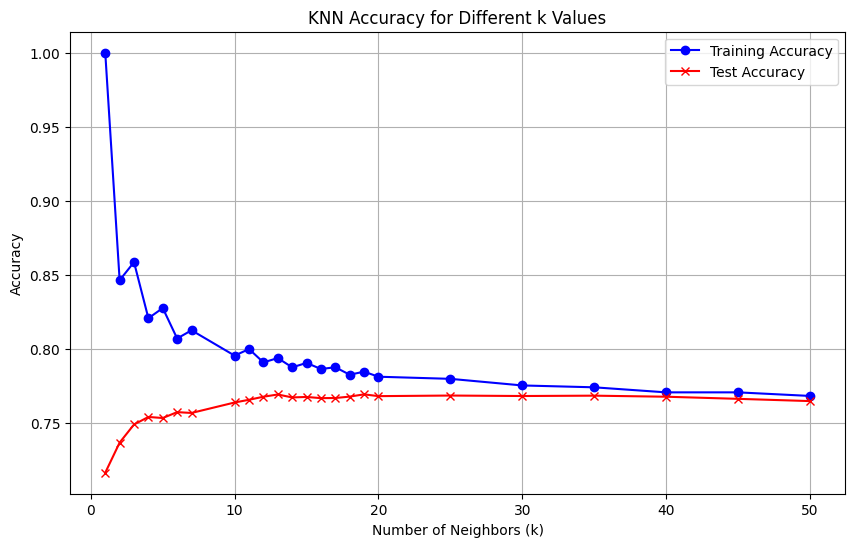

In [6]:
numNeighbors = [1, 2, 3, 4, 5, 6, 7, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 25, 30, 35, 40, 45, 50]
trainAcc = []
testAcc = []

for k in numNeighbors:
    clf1 = KNeighborsClassifier(n_neighbors=k, metric='minkowski', p=2)
    clf1.fit(X_train, y_train)
    Y_predTrain = clf1.predict(X_train)
    Y_predTest = clf1.predict(X_test)

    train_accuracy = accuracy_score(y_train, Y_predTrain)
    test_accuracy = accuracy_score(y_test, Y_predTest)

    trainAcc.append(accuracy_score(y_train, Y_predTrain))
    testAcc.append(accuracy_score(y_test, Y_predTest))

    print(f'k={k}, Training Accuracy: {train_accuracy:.4f}, Test Accuracy: {test_accuracy:.4f}')    

plt.figure(figsize=(10, 6))
plt.plot(numNeighbors, trainAcc, label='Training Accuracy', marker='o', color='blue')
plt.plot(numNeighbors, testAcc, label='Test Accuracy', marker='x', color='red')

plt.title('KNN Accuracy for Different k Values')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

## Neural Network

hidden_layer_sizes=(5, 5, 5), Training Accuracy: 0.8425, Test Accuracy: 0.8398
hidden_layer_sizes=(6, 6, 6), Training Accuracy: 0.8475, Test Accuracy: 0.8442
hidden_layer_sizes=(7, 7, 7), Training Accuracy: 0.8521, Test Accuracy: 0.8507
hidden_layer_sizes=(10, 10, 10), Training Accuracy: 0.8559, Test Accuracy: 0.8536
hidden_layer_sizes=(20, 20, 20), Training Accuracy: 0.8553, Test Accuracy: 0.8513
hidden_layer_sizes=(30, 30, 30), Training Accuracy: 0.8593, Test Accuracy: 0.8549
hidden_layer_sizes=(40, 40, 40), Training Accuracy: 0.8632, Test Accuracy: 0.8590


Text(0, 0.5, 'Accuracy')

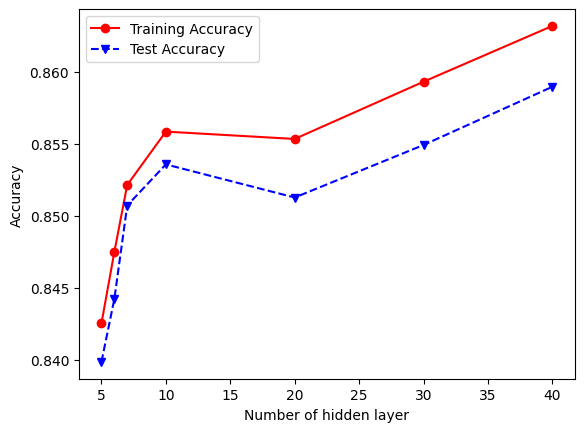

In [17]:
hidden_layer_sizes = [(5,5,5), (6,6,6), (7,7,7),(10,10,10), (20,20,20), (30,30,30), (40,40,40)]
trainAcc = []
testAcc = []

for k in hidden_layer_sizes:
    clf6 = MLPClassifier(solver='adam',hidden_layer_sizes=k, learning_rate_init= 0.0005, activation='relu', random_state=1,max_iter=2000, batch_size=32)    
    clf6.fit(X_train, y_train)
    Y_predTrain = clf6.predict(X_train)
    Y_predTest = clf6.predict(X_test)
    trainAcc.append(accuracy_score(y_train, Y_predTrain))
    testAcc.append(accuracy_score(y_test, Y_predTest))
    print(f'hidden_layer_sizes={k}, Training Accuracy: {accuracy_score(y_train, Y_predTrain):.4f}, Test Accuracy: {accuracy_score(y_test, Y_predTest):.4f}')
    
hidden_layer_size=[x[0] for x in hidden_layer_sizes]
plt.plot(hidden_layer_size, trainAcc, 'ro-', hidden_layer_size, testAcc,'bv--')
plt.legend(['Training Accuracy','Test Accuracy'])
plt.xlabel('Number of hidden layer')
plt.ylabel('Accuracy')

# Prediction of range

## Load Dataset

In [8]:
file_directory = "./Cleaned_Data"

original_df_range = pd.read_csv(os.path.join(file_directory,"Range_Cleaned_Data.csv"))

original_df_range = original_df_range.drop(columns = ['Unnamed: 0'])

original_df_range.head()

X = original_df_range.drop(['RANGE'] , axis=1)
y = original_df_range['RANGE']

X_train_range, X_test_range, y_train_range, y_test_range = train_test_split(X, y, test_size=0.3, random_state=42)

## Multilinear Regression

In [9]:
param_grid = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100]}
ridge = Ridge()
grid_search = GridSearchCV(ridge, param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(X_train_range, y_train_range)

# Get the best parameters
best_alpha = grid_search.best_params_['alpha']
print(f"Best alpha: {best_alpha}")

# Use the best estimator (which has the optimal parameters already set)
best_ridge = grid_search.best_estimator_
y_pred_range = best_ridge.predict(X_test_range)

# Calculate metrics
mse = mean_squared_error(y_test_range, y_pred_range)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_range, y_pred_range)

# Print the results
print(f"Ridge Regression's Mean Squared Error: {mse:.4f}")
print(f"Ridge Regression's Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Ridge Regression's R-squared: {r2:.4f}")


# Define parameter grid for Lasso
lasso_param_grid = {'alpha': [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0]}
lasso = Lasso(max_iter=10000)  # Increase max_iter to ensure convergence

# Perform grid search
lasso_grid_search = GridSearchCV(lasso, lasso_param_grid, cv=5, scoring='neg_mean_squared_error')
lasso_grid_search.fit(X_train_range, y_train_range)

# Get best parameters
best_lasso_alpha = lasso_grid_search.best_params_['alpha']
print(f"Best Lasso alpha: {best_lasso_alpha}")

# Use the best estimator
best_lasso = lasso_grid_search.best_estimator_
y_pred_range = best_lasso.predict(X_test_range)

# Calculate metrics
mse = mean_squared_error(y_test_range, y_pred_range)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_range, y_pred_range)

# Print the results
print(f"Lasso Regression's Mean Squared Error: {mse:.4f}")
print(f"Lasso Regression's Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Lasso Regression's R-squared: {r2:.4f}")


# Create a pipeline with scaling and linear regression
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])

# Since LinearRegression doesn't have alpha hyperparameters like Ridge or Lasso,
# we'll optimize for fit_intercept
param_grid = {'regressor__fit_intercept': [True, False]}

# Perform grid search
pipeline_grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='neg_mean_squared_error')
pipeline_grid_search.fit(X_train_range, y_train_range)

# Get best parameters
best_fit_intercept = pipeline_grid_search.best_params_['regressor__fit_intercept']
print(f"Best fit_intercept: {best_fit_intercept}")

# Use the best estimator
best_pipeline = pipeline_grid_search.best_estimator_
y_pred_range = best_pipeline.predict(X_test_range)

# Calculate metrics
mse = mean_squared_error(y_test_range, y_pred_range)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_range, y_pred_range)

# Print the results
print(f"Scaled Linear Regression's Mean Squared Error: {mse:.4f}")
print(f"Scaled Linear Regression's Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Scaled Linear Regression's R-squared: {r2:.4f}")

Best alpha: 0.001
Ridge Regression's Mean Squared Error: 2.8228
Ridge Regression's Root Mean Squared Error (RMSE): 1.6801
Ridge Regression's R-squared: 0.4841
Best Lasso alpha: 0.0001
Lasso Regression's Mean Squared Error: 2.8228
Lasso Regression's Root Mean Squared Error (RMSE): 1.6801
Lasso Regression's R-squared: 0.4841
Best fit_intercept: True
Scaled Linear Regression's Mean Squared Error: 2.8228
Scaled Linear Regression's Root Mean Squared Error (RMSE): 1.6801
Scaled Linear Regression's R-squared: 0.4841


## Artificial Neural Networks

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import mean_squared_error, r2_score

# Scaling data
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train_range)
X_test_scaled = scaler_X.transform(X_test_range)

y_train_scaled = scaler_y.fit_transform(y_train_range.values.reshape(-1, 1)) 
y_test_scaled = scaler_y.transform(y_test_range.values.reshape(-1, 1))

# Define the improved ANN model
model = Sequential()
model.add(Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(256, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(128, activation='relu'))
model.add(Dense(1))  # Output layer

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='mean_squared_error',
              metrics=['mean_absolute_error', 'mean_squared_error'])

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-5)

# Train the model
history = model.fit(X_train_scaled, y_train_scaled,
                    batch_size=32,
                    epochs=100,
                    validation_data=(X_test_scaled, y_test_scaled),
                    shuffle=True,
                    callbacks=[early_stop, reduce_lr],
                    verbose=1)

# Evaluate
y_test_pred_scaled = model.predict(X_test_scaled)
y_test_pred = scaler_y.inverse_transform(y_test_pred_scaled)
y_test_true = scaler_y.inverse_transform(y_test_scaled)

mse = mean_squared_error(y_test_true, y_test_pred)
rse = np.sqrt(mse)
r2 = r2_score(y_test_true, y_test_pred)

print(f"Improved ANN MSE: {mse:.4f}")
print(f"Improved ANN RMSE: {rse:.4f}")
print(f"Improved ANN R² Score: {r2:.4f}")

Epoch 1/100


c:\Users\triam\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


919/919 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.8574 - mean_absolute_error: 0.7172 - mean_squared_error: 0.8574 - val_loss: 0.4165 - val_mean_absolute_error: 0.5130 - val_mean_squared_error: 0.4165 - learning_rate: 0.0010
Epoch 2/100
919/919 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.4759 - mean_absolute_error: 0.5425 - mean_squared_error: 0.4759 - val_loss: 0.3764 - val_mean_absolute_error: 0.4811 - val_mean_squared_error: 0.3764 - learning_rate: 0.0010
Epoch 3/100
919/919 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.4326 - mean_absolute_error: 0.5123 - mean_squared_error: 0.4326 - val_loss: 0.3583 - val_mean_absolute_error: 0.4652 - val_mean_squared_error: 0.3583 - learning_rate: 0.0010
Epoch 4/100
919/919 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.4196 - mean_absolute_error: 0.5068 - mean_squared_error: 0.4196 - val_loss: 0.3557 - val_mean_absolute_error: 0.4643 - val_mean_squared_error: 0.3557 - learning_rate: 0.0010
Epoch 5/100
919/919 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.4

## Random Forest Regression

In [13]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score

# Refined and compact parameter space
param_dist = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [20, 30, 40, 50, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False]
}

# Initialize Random Forest
rf = RandomForestRegressor(random_state=42)

# Randomized Search (20 iterations)
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=25,               # Number of random combos to try
    scoring='r2',
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Train
random_search.fit(X_train_range, y_train_range)

# Best model from search
best_rf = random_search.best_estimator_

# Predict
y_pred_range = best_rf.predict(X_test_range)

# Evaluate
mse = mean_squared_error(y_test_range, y_pred_range)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_range, y_pred_range)

print("📌 Best Parameters:", random_search.best_params_)
print(f"📉 RandomizedSearch MSE: {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"📈 RandomizedSearch R² Score: {r2:.4f}")


Fitting 5 folds for each of 25 candidates, totalling 125 fits
📌 Best Parameters: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 30, 'bootstrap': False}
📉 RandomizedSearch MSE: 1.9245
Root Mean Squared Error (RMSE): 1.3873
📈 RandomizedSearch R² Score: 0.6483


## XGBoost Regressor

In [14]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Basic XGBoost model
xgb = XGBRegressor(objective='reg:squarederror', random_state=42)

# Hyperparameter grid (can tune more later)
param_dist = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

# Randomized Search CV
random_search_xgb = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=30,
    scoring='r2',
    cv=5,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

# Fit model
random_search_xgb.fit(X_train_range, y_train_range)

# Best model
best_xgb = random_search_xgb.best_estimator_

# Predict
y_pred_xgb = best_xgb.predict(X_test_range)

# Evaluation
mse_xgb = mean_squared_error(y_test_range, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
r2_xgb = r2_score(y_test_range, y_pred_xgb)

# Results
print("📌 Best Parameters:", random_search_xgb.best_params_)
print(f"📉 XGBoost MSE: {mse_xgb:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_xgb:.4f}")
print(f"📈 XGBoost R² Score: {r2_xgb:.4f}")


Fitting 5 folds for each of 30 candidates, totalling 150 fits
📌 Best Parameters: {'subsample': 0.8, 'n_estimators': 400, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 0.6}
📉 XGBoost MSE: 1.8612
Root Mean Squared Error (RMSE): 1.3643
📈 XGBoost R² Score: 0.6599
